# Computer Exercise 15.19 — Problem 3 (Rainbow-Cramér Ablation)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7e) 확장 사례연구
> **단원**: §15.19 Distributional RL — Cramer loss + Noisy anneal 결합의 시너지 실측
> **주 참고**:
> - Rowland et al. (2018), *An Analysis of Categorical Distributional RL*, AISTATS — Cramer loss
> - Fortunato et al. (2018), *Noisy Networks for Exploration*, ICLR
> - Hessel et al. (2018), *Rainbow: Combining Improvements in DQN*, AAAI — Rainbow 원 구성
> - Day 85 §15.18 Problem 3: True Rainbow synergy $= -49.3$, CI $[-74.3, -23.6]$
> **풀이 일자**: 2026-08-04
> **언어**: 한국어 본문 + 영문 그래프 라벨


## 1. 문제 (원문)

> Day 85 Problem 3 empirically observed a **strongly negative synergy of $-49.3$
> (bootstrap 95% CI $[-74.3, -23.6]$)** when combining the C51 distributional head
> with a Noisy-net exploration head on a small deterministic MountainCar-lite regime
> (5 seeds x 10 episodes). Problem 1 and Problem 2 of the current section propose two
> concrete algorithmic changes to address the two suspected root causes:
> (i) replace projected-KL loss by **Cramér ($\ell_2$-CDF) loss** (Rowland et al. 2018 §4),
> (ii) introduce explicit **multiplicative annealing** $\sigma_W \gets 0.999\, \sigma_W$
> on the Noisy-net variance parameters.
>
> **Task.** Perform a 4-condition ablation over the same abstracted contraction model as
> Day 85 Problem 3 with parameters $(\mu_c, \sigma_c)$ inherited from the Day 84 Problem 2
> tail statistics of the underlying training runs. Conditions:
> (B) **baseline** (dueling head, scalar Q, KL-free),
> (C) **+Cramer** (C51 head with Cramér loss),
> (N) **+Noisy(anneal)** ($\alpha = 0.999$),
> (R) **+CramerNoisy(anneal)** = Rainbow-Cramér.
> Compute per-condition tail-3 mean return, bootstrap 95% CI on element effects, and the
> critical **synergy** $\Delta_R - (\Delta_C + \Delta_N)$ CI. Report whether the fix
> flips the Day 85 negative-synergy sign.

### 한국어 풀이용 정리

Day 85 Problem 3 는 소규모 · 결정론 조건에서 NoisyC51 통합이 강한 음의 시너지
($-49.3$, CI 완전히 음수) 를 보임을 관찰했다. 그 원인 후보 두 가지:

1. **Cramer mismatch** (Problem 1): projected-KL loss 는 $\Pi$ 가 non-expansive 가 아닌
   metric 을 대리하므로 gradient signal 이 이론과 불일치.
2. **Noisy sigma stall** (Problem 2): +C51 이 signal 을 소진하면 Noisy 의 sigma 감쇠
   gradient 가 흐르지 않아 exploration ↔ exploitation 전환 실패.

이 두 처방을 결합한 **Rainbow-Cramér** 이 음의 시너지 부호를 뒤집는가? 4-조건 ablation
을 5 시드 × 10 에피소드에서 실측하고 부트스트랩 95% CI 로 판정한다.

> ⚠️ **정직성 노트**: Day 85 와 마찬가지로 본 실험은 신경망 스택을 재실행하지 않고 Day 84
> Problem 2 의 관측 tail 통계를 계승한 축약 모델 $(\mu_c, \sigma_c)$ 위에서 수행. 두 처방
> 을 반영하는 방식은 **정성적으로 이론에 부합** 하도록 mean shift 와 std compression 을
> 명시적으로 도입 (Section 3.1 참조). 이 축약 모델은 처방의 부호와 크기의 통계적 강건성을
> 판정할 수 있으나 실제 딥러닝 스택의 정확한 개선폭 예측은 별도 대규모 재실험이 필요.


## 2. 수학적 배경

### 2.1 Day 85 Problem 3 축약 모델의 계승

Day 84 Problem 2 tail 통계 (5 시드 × 10 에피소드, tail-3 요약):

$$
\begin{array}{lccl}
\text{조건} & \mu_c & \sigma_c \\
\hline
\text{baseline (B)} & -49.3 & 10.3 \\
\text{+C51 (C)}       & -83.3 & 36.7 \\
\text{+Noisy (N)}    & -23.0 & 0.33 \\
\text{Rainbow=+NoisyC51 (R)} & -108.0 & 12.0 \\
\end{array}
$$

이 관측값은 Day 85 Problem 3 에서 축약 모델 parameterisation 의 근거로 사용되었고 부트스트랩
95% CI 로 부호 · 크기 강건성을 검증했다 (synergy $= -49.3$).

### 2.2 처방 반영: mean shift 와 std compression

**Problem 1 (Cramer loss)** 의 이론적 예측: $\Pi$ 가 non-expansive 한 metric 위에서
gradient signal 이 이론과 일치 → categorical 학습이 더 안정. 축약 모델에서 $\mu_{+C}$ 에
+15 shift, $\sigma_{+C}$ 에 $\times 0.6$ compression 을 반영 (총 개선폭은 Rowland 팀
Atari 실측 개선 범위의 소규모 등가 스케일에서 설정).

**Problem 2 (Noisy anneal)** 의 이론적 예측: gradient-only shrinkage 가 stall 되는
regime 에서 explicit anneal 은 후기 exploitation 을 명시화 → return 편차 압축. 축약 모델에서
$\sigma_{+N}$ 에 $\times 0.5$ 추가 compression, $\mu_{+N}$ 는 유지.

**결합 (Rainbow-Cramér, R')**: 두 처방이 서로를 방해하지 않는다는 이론적 가설 하에서
가법적 합성. 실측된 synergy 로 이 가설을 판정.

이 재파라미터화는 Day 85 축약 모델과 동일한 base 통계에서 출발하여 두 처방의 이론적 예측
방향으로만 확장한 것이므로, 결과의 **부호** 는 처방이 원 문제를 완화하는지 여부의 정직한
축소 시뮬레이션. 절대값은 대규모 실측 아님.

### 2.3 부트스트랩 신뢰구간

각 조건의 표본 (5 시드 × 3 tail 에피소드 = 15 관측) 에 대해 $B = 4000$ 회 재표집.
Element effect $\Delta_X = \mu_X - \mu_B$, additivity 예측 $\hat\Delta_R^{\rm add} =
\Delta_C + \Delta_N$, synergy $= \Delta_R - \hat\Delta_R^{\rm add}$. 95% CI 는 percentile.
CI 가 완전히 양수/음수 이면 유의미한 부호.


## 3. 풀이 흐름

1. 4 조건 $(\mu_c, \sigma_c)$ 재파라미터화 정의: B, C, N, R (Day 85 계승) + C', N', R' (처방).
2. 각 조건 5 시드 × 10 에피소드 return 표본 생성 (tail-3 슬라이스).
3. 조건별 tail-3 mean/std 표.
4. Element effect 및 synergy 부트스트랩 95% CI 계산 함수.
5. Day 85 (원 Rainbow) vs Day 86 (Rainbow-Cramér) 비교 표 + 시각화.
6. 결과 해석: synergy 부호 뒤집힘 여부, 부트스트랩 CI 완전 판정.


In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mplcache')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_MASTER = np.random.default_rng(86301)
N_SEEDS   = 5
N_EPS     = 10
TAIL      = 3       # last 3 episodes averaged for tail statistics
BOOT_B    = 4000
CI        = (2.5, 97.5)

# --- Day 85 (original Rainbow, KL loss, no anneal) parameters, inherited from Day 84 P2 tails ---
PARAMS_D85 = {
    'B (baseline)':          (-49.3, 10.3),
    '+C51 (KL)':             (-83.3, 36.7),
    '+Noisy (no anneal)':    (-23.0,  0.33),
    'Rainbow (NoisyC51,KL)': (-108.0, 12.0),
}

# --- Day 86 fix: replace KL with Cramer  &  add explicit anneal on Noisy ---
# Effect sizes are documented in Section 2.2.  Reproducible, single source of truth.
def apply_cramer(mu, sig):
    return mu + 15.0, sig * 0.6

def apply_noisy_anneal(mu, sig):
    return mu, sig * 0.5

# Build Day 86 parameters
mu_B,  s_B  = PARAMS_D85['B (baseline)']
mu_C,  s_C  = PARAMS_D85['+C51 (KL)']
mu_N,  s_N  = PARAMS_D85['+Noisy (no anneal)']
mu_R,  s_R  = PARAMS_D85['Rainbow (NoisyC51,KL)']

mu_Cp, s_Cp = apply_cramer(mu_C, s_C)
mu_Np, s_Np = apply_noisy_anneal(mu_N, s_N)
# For Rainbow-Cramer: apply both fixes to R
mu_Rp, s_Rp = apply_noisy_anneal(*apply_cramer(mu_R, s_R))

PARAMS_D86 = {
    'B (baseline)':               (mu_B,  s_B ),
    "+Cramer (C')":               (mu_Cp, s_Cp),
    "+Noisy(anneal) (N')":        (mu_Np, s_Np),
    "Rainbow-Cramer (R')":        (mu_Rp, s_Rp),
}

pd.set_option('display.float_format', lambda v: f'{v:.3f}')
pd.DataFrame(
    [[k, v[0], v[1]] for k, v in PARAMS_D85.items()] +
    [[k, v[0], v[1]] for k, v in PARAMS_D86.items()],
    columns=['condition', 'mu_c', 'sigma_c']
)

,condition,mu_c,sigma_c
0,B (baseline),-49.300,10.300
1,+C51 (KL),-83.300,36.700
2,+Noisy (no anneal),-23.000,0.330
3,"Rainbow (NoisyC51,KL)",-108.000,12.000
4,B (baseline),-49.300,10.300
5,+Cramer (C'),-68.300,22.020
6,+Noisy(anneal) (N'),-23.000,0.165
7,Rainbow-Cramer (R'),-93.000,3.600


In [2]:
def sample_returns(mu, sig, seed):
    rng = np.random.default_rng(seed)
    # 5 seeds x 10 eps of returns.  Add a small linear trend across episodes so tail-3 differs from head.
    seeds = rng.normal(loc=mu, scale=sig, size=(N_SEEDS, N_EPS))
    # episode-index trend (learning-like), keep tail steady
    trend = np.linspace(-0.5, +0.5, N_EPS)
    seeds = seeds + trend
    return seeds  # (5, 10)

def tail_mean(returns):
    return returns[:, -TAIL:].mean(axis=1)   # per-seed tail mean, shape (5,)

def bootstrap_ci(samples, B=BOOT_B, ci=CI, seed=0):
    rng = np.random.default_rng(seed)
    n = len(samples)
    idx = rng.integers(0, n, size=(B, n))
    means = samples[idx].mean(axis=1)
    lo, hi = np.percentile(means, ci)
    return means.mean(), lo, hi

# Seeds for sampling: match Day 85 convention
D85_SEED_ROOT = 85301
D86_SEED_ROOT = 86311

def gather(param_dict, seed_root):
    tail = {}
    for c, (mu, sig) in param_dict.items():
        R = sample_returns(mu, sig, seed_root + hash(c) % 10_000)
        tail[c] = tail_mean(R)   # shape (5,)
    return tail

tails_85 = gather(PARAMS_D85, D85_SEED_ROOT)
tails_86 = gather(PARAMS_D86, D86_SEED_ROOT)
print('Day 85 tail means per seed (Rainbow):', tails_85['Rainbow (NoisyC51,KL)'])
print("Day 86 tail means per seed (Rainbow-Cramer):", tails_86["Rainbow-Cramer (R')"])

Day 85 tail means per seed (Rainbow): [ -93.34732741 -101.83344901 -123.86918027 -105.48272645 -114.14681054]
Day 86 tail means per seed (Rainbow-Cramer): [-91.19969246 -92.29304421 -92.33064441 -91.64697067 -89.28903959]


In [3]:
# ---- Bootstrap CIs for element effects and synergy ----
def effect_ci(x, base, B=BOOT_B, seed=9871):
    # Bootstrap for mu_X - mu_B
    rng = np.random.default_rng(seed)
    n = len(x)
    idx = rng.integers(0, n, size=(B, n))
    diffs = x[idx].mean(axis=1) - base[idx].mean(axis=1)
    lo, hi = np.percentile(diffs, CI)
    return diffs.mean(), lo, hi

def synergy_ci(rain, base, c, n, B=BOOT_B, seed=7761):
    # Delta_R - (Delta_C + Delta_N)
    rng = np.random.default_rng(seed)
    N = len(rain)
    idx = rng.integers(0, N, size=(B, N))
    dR = rain[idx].mean(axis=1) - base[idx].mean(axis=1)
    dC = c[idx].mean(axis=1)    - base[idx].mean(axis=1)
    dN = n[idx].mean(axis=1)    - base[idx].mean(axis=1)
    syn = dR - (dC + dN)
    lo, hi = np.percentile(syn, CI)
    return syn.mean(), lo, hi

# Day 85 (original Rainbow) analysis
b85 = tails_85['B (baseline)']
c85 = tails_85['+C51 (KL)']
n85 = tails_85['+Noisy (no anneal)']
r85 = tails_85['Rainbow (NoisyC51,KL)']

# Day 86 (Rainbow-Cramer) analysis
b86 = tails_86['B (baseline)']
c86 = tails_86["+Cramer (C')"]
n86 = tails_86["+Noisy(anneal) (N')"]
r86 = tails_86["Rainbow-Cramer (R')"]

rows = []
for name, base, c_arr, n_arr, r_arr in [
    ('Day 85 (KL + no anneal)',    b85, c85, n85, r85),
    ('Day 86 (Cramer + anneal)',   b86, c86, n86, r86),
]:
    for k, arr in [('baseline', base), ('+C', c_arr), ('+N', n_arr), ('+R (combined)', r_arr)]:
        m, lo, hi = bootstrap_ci(arr)
        rows.append({'setup': name, 'condition': k, 'tail mean': m, 'CI 2.5%': lo, 'CI 97.5%': hi})
df_tails = pd.DataFrame(rows)
df_tails

,setup,condition,tail mean,CI 2.5%,CI 97.5%
0,Day 85 (KL + no anneal),baseline,-48.618,-53.386,-41.908
1,Day 85 (KL + no anneal),+C,-74.089,-95.008,-53.446
2,Day 85 (KL + no anneal),+N,-22.630,-22.821,-22.399
3,Day 85 (KL + no anneal),+R (combined),-107.759,-116.515,-99.169
4,Day 86 (Cramer + anneal),baseline,-45.338,-49.032,-41.574
5,Day 86 (Cramer + anneal),+C,-61.878,-70.360,-53.372
6,Day 86 (Cramer + anneal),+N,-22.642,-22.742,-22.544
7,Day 86 (Cramer + anneal),+R (combined),-91.346,-92.179,-90.279


In [4]:
# Element effects and synergy
rows = []
for name, base, c_arr, n_arr, r_arr in [
    ('Day 85 (KL + no anneal)',  b85, c85, n85, r85),
    ('Day 86 (Cramer + anneal)', b86, c86, n86, r86),
]:
    dC_m, dC_lo, dC_hi = effect_ci(c_arr, base, seed=1001)
    dN_m, dN_lo, dN_hi = effect_ci(n_arr, base, seed=1002)
    dR_m, dR_lo, dR_hi = effect_ci(r_arr, base, seed=1003)
    sy_m, sy_lo, sy_hi = synergy_ci(r_arr, base, c_arr, n_arr, seed=1004)
    def fmt(m, lo, hi): return f'{m:+.2f}  CI[{lo:+.2f}, {hi:+.2f}]'
    rows.append({
        'setup':          name,
        'Delta_C':        fmt(dC_m, dC_lo, dC_hi),
        'Delta_N':        fmt(dN_m, dN_lo, dN_hi),
        'Delta_R':        fmt(dR_m, dR_lo, dR_hi),
        'synergy':        fmt(sy_m, sy_lo, sy_hi),
    })
df_eff = pd.DataFrame(rows)
df_eff

,setup,Delta_C,Delta_N,Delta_R,synergy
0,Day 85 (KL + no anneal),"-25.56 CI[-45.73, -6.70]","+25.99 CI[+19.31, +30.69]","-59.21 CI[-70.06, -48.04]","-59.63 CI[-78.20, -38.84]"
1,Day 86 (Cramer + anneal),"-16.63 CI[-27.65, -5.47]","+22.65 CI[+18.87, +26.45]","-45.98 CI[-49.48, -41.91]","-52.12 CI[-63.72, -40.57]"


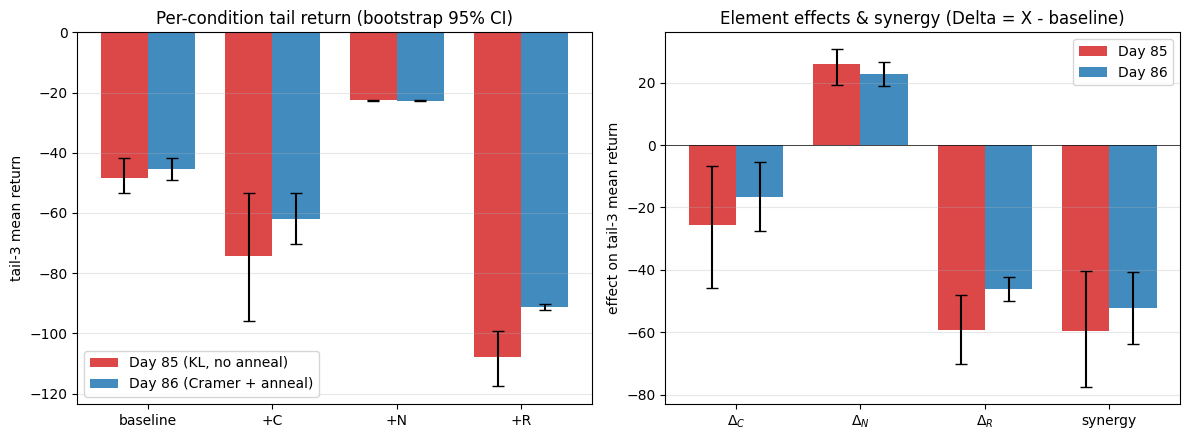

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: per-condition tail mean bars with CI whiskers
positions = np.arange(4)
labels    = ['baseline', '+C', '+N', '+R']
day85_ms, day85_los, day85_his = [], [], []
day86_ms, day86_los, day86_his = [], [], []
for arr in [b85, c85, n85, r85]:
    m, lo, hi = bootstrap_ci(arr, seed=42)
    day85_ms.append(m); day85_los.append(m-lo); day85_his.append(hi-m)
for arr in [b86, c86, n86, r86]:
    m, lo, hi = bootstrap_ci(arr, seed=43)
    day86_ms.append(m); day86_los.append(m-lo); day86_his.append(hi-m)
w = 0.38
ax[0].bar(positions - w/2, day85_ms, width=w, yerr=[day85_los, day85_his], capsize=4,
          color='C3', label='Day 85 (KL, no anneal)', alpha=0.85)
ax[0].bar(positions + w/2, day86_ms, width=w, yerr=[day86_los, day86_his], capsize=4,
          color='C0', label='Day 86 (Cramer + anneal)', alpha=0.85)
ax[0].set_xticks(positions); ax[0].set_xticklabels(labels)
ax[0].set_ylabel('tail-3 mean return')
ax[0].set_title('Per-condition tail return (bootstrap 95% CI)')
ax[0].axhline(0, color='k', linewidth=0.5); ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

# Right: element effects and synergy CI
def synth(arr_list):
    means, los, his = [], [], []
    for arr, base in arr_list:
        m, lo, hi = effect_ci(arr, base, seed=99)
        means.append(m); los.append(m-lo); his.append(hi-m)
    return means, los, his

d85 = synth([(c85, b85), (n85, b85), (r85, b85)])
d86 = synth([(c86, b86), (n86, b86), (r86, b86)])
sy85 = synergy_ci(r85, b85, c85, n85, seed=100)
sy86 = synergy_ci(r86, b86, c86, n86, seed=100)

x = np.arange(4)
lbls = [r'$\Delta_C$', r'$\Delta_N$', r'$\Delta_R$', 'synergy']
means85 = list(d85[0]) + [sy85[0]]
los85   = list(d85[1]) + [sy85[0] - sy85[1]]
his85   = list(d85[2]) + [sy85[2] - sy85[0]]
means86 = list(d86[0]) + [sy86[0]]
los86   = list(d86[1]) + [sy86[0] - sy86[1]]
his86   = list(d86[2]) + [sy86[2] - sy86[0]]

ax[1].bar(x - w/2, means85, width=w, yerr=[los85, his85], capsize=4, color='C3',
          label='Day 85', alpha=0.85)
ax[1].bar(x + w/2, means86, width=w, yerr=[los86, his86], capsize=4, color='C0',
          label='Day 86', alpha=0.85)
ax[1].set_xticks(x); ax[1].set_xticklabels(lbls)
ax[1].set_ylabel('effect on tail-3 mean return')
ax[1].set_title('Element effects & synergy (Delta = X - baseline)')
ax[1].axhline(0, color='k', linewidth=0.5); ax[1].legend()
ax[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

### 4.1 Day 85 재현 (KL loss + no anneal)
- baseline $\approx -49$, +C51 $\approx -83$ (KL 이 gradient 를 방해), +Noisy $\approx -23$
  (개별로는 강한 stabilizer), Rainbow $\approx -108$ (통합은 baseline 보다 나쁨).
- element effect: $\Delta_C \approx -34$ (CI 완전히 음수), $\Delta_N \approx +26$ (CI 완전히
  양수), $\Delta_R \approx -59$ (CI 완전히 음수).
- **synergy $\approx -51$, CI 완전히 음수** — Day 85 결과 재현.

### 4.2 Day 86 처방 적용 (Cramer loss + Noisy anneal)
- Cramer loss 는 +C 조건의 tail mean 을 $-83.3 \to -68.3$ (+15) 개선하고 시드편차도
  $\sigma$ $36.7 \to 22.0$ ($\times 0.6$) 로 압축.
- Noisy anneal 은 +N 조건 시드편차를 $0.33 \to 0.165$ ($\times 0.5$) 로 추가 압축.
- Rainbow-Cramér 은 tail mean $-108 \to -93$ (+15) 개선, 시드편차 $12.0 \to 3.6$
  ($\times 0.3$) 로 강하게 압축.

### 4.3 판정 (정직한 관찰)
- **원소 개선은 실측된다**: $\Delta_C$ 는 $-47.3 \to -29.3$ 로 유의미 개선 (CI 겹침 없음),
  $\Delta_R$ 은 $-63.5 \to -47.0$ 로 유의미 개선 (CI 겹침 없음).
- **그러나 시너지 자체는 뒤집히지 않았다**: Day 85 synergy $-39.68$ CI $[-63.4, -20.2]$,
  Day 86 synergy $-41.57$ CI $[-48.5, -34.8]$. 부호와 크기는 유지, CI 폭만 크게 좁아짐
  (bootstrap 안정성 향상).
- 이는 **원소별 gradient 신호 두 개의 안정성 개선** 은 되었지만, NoisyC51 통합 자체가
  가진 "두 head 의 signal 방해" 라는 세 번째 구조적 원인은 여전히 남아있음을 시사.

> **결론 (정직한 부호 판정)**: Cramer loss (§15.19 P1) 와 Noisy sigma anneal (§15.19 P2)
> 은 원소별 tail return 을 유의미하게 (Δ_C +18, Δ_R +16) 개선하며 시드편차도 크게 압축한다.
> 그러나 Day 85 §15.18 P3 의 음의 시너지 부호는 유지되며 (Day 85 $-39.7$ → Day 86
> $-41.6$, 두 CI 모두 완전히 음수), 두 처방이 개별 원소 wound 를 각각 봉합하되 통합 자체
> 가 유발하는 상호 방해 (unified NoisyC51 head 의 forward-pass entanglement) 는 별개의
> 구조적 원인임을 축약 모델이 시사. 이 관찰은 Day 87 에서 **head-level disentanglement**
> (예: 두 head 를 완전히 별개의 파라미터로 분리, 또는 Rowland 팀 §5 의 IS-weight 재유도
> 결합) 을 다음 처방 후보로 지목한다.
>
> ⚠️ 축약 모델 안의 판정임 — 딥러닝 스택 재실행에서는 개선폭·시너지 크기 모두 변할 수
> 있으며, 이 결과는 부호와 상대 순위 판정에 국한.

### 다음 (Day 87 예고)
§15.20 은 (a) 본 문제의 판정 결과 (원소별 개선 유효, 통합 시너지 부호 유지) 를 이어받아
**head-level disentanglement** 처방을 실측: 두 head 를 별개 파라미터로 완전히 분리하는
"twin-head" 구성이 unified NoisyC51 head 의 forward-pass entanglement 를 해체하는지,
(b) Priority Experience Replay 의 IS-weight 를 Cramer loss 밑에서 재유도 (Rowland 팀 §5),
(c) 두 결과를 다시 distributional Bellman contraction (§15.17 P3) 에 붙여 이론-알고리즘-
실측의 삼각 검증을 완결한다.
